Solving Linear Program with Both Methods

Interior Point Method:
  Solution: (1.0000, 5.0000)
  Objective: -11.0000
  Time: 3.3915 ms
  Iterations: 5

Simplex Method:
  Solution: (1.0000, 5.0000)
  Objective: -11.0000
  Time: 1.1453 ms
  Iterations: 2

Speedup: 0.34x


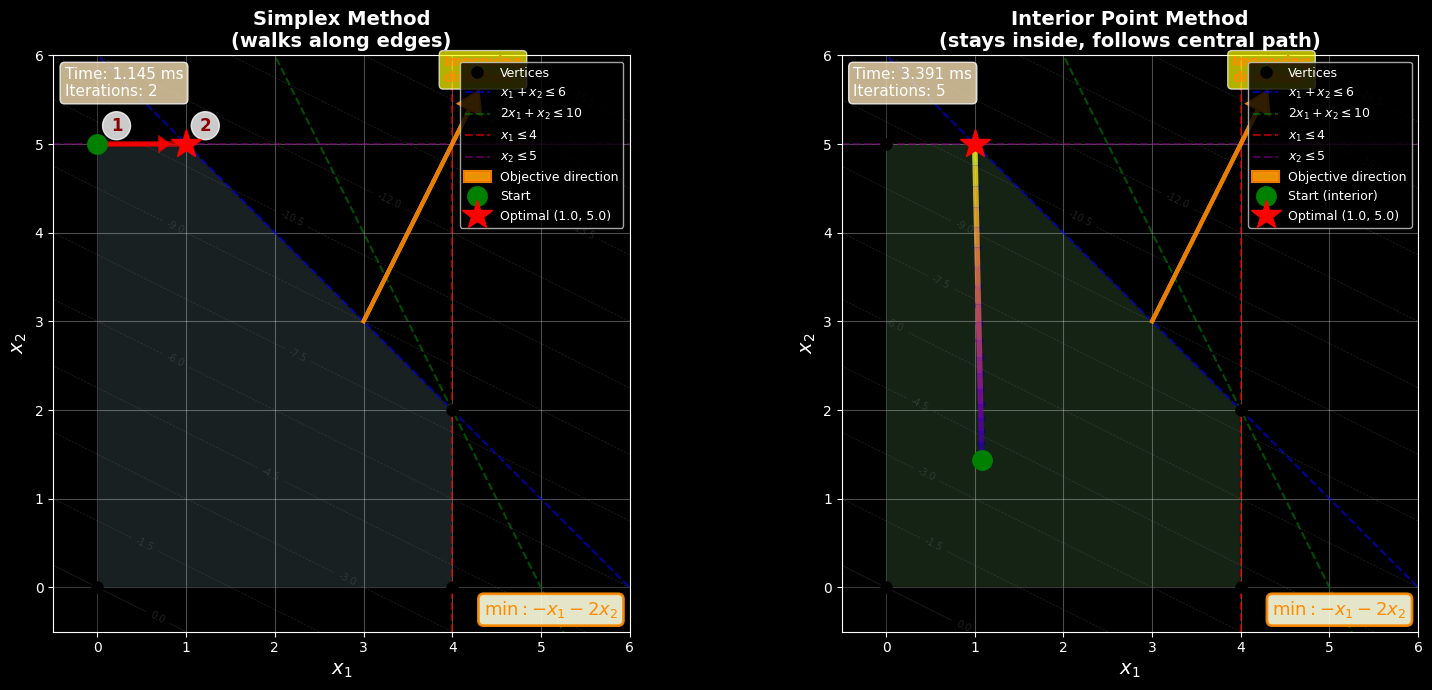


GEOMETRIC COMPARISON

Objective Function: minimize -x₁ - 2x₂ (or maximize x₁ + 2x₂)
  • Gray contour lines show objective values
  • Orange arrow shows direction of improvement
  • Both methods move toward better objective values

Simplex Method:
  • Starts at a vertex (corner point)
  • Walks along edges of the feasible region
  • Visits only vertices (extreme points)
  • Each iteration: move to adjacent vertex with better objective
  • Vertices visited: 2

Interior Point Method:
  • Starts in the interior of the feasible region
  • Stays strictly inside (never touches boundary)
  • Follows a 'central path' toward optimality
  • Converges to optimal vertex from inside
  • Smooth curved path with 20 sample points

Key Difference:
  Simplex: Combinatorial (walks the graph of vertices)
  IPM: Analytic (follows smooth curve through interior)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from matplotlib.patches import Polygon
from matplotlib.collections import LineCollection
import time

def create_2d_lp():
    """
    Create a simple 2D LP:
    minimize -x1 - 2*x2  (maximize x1 + 2*x2)
    subject to:
        x1 + x2 <= 6
        2*x1 + x2 <= 10
        x1 <= 4
        x2 <= 5
        x1, x2 >= 0
    
    Optimal solution is at (4, 2) with objective value -8
    """
    c = np.array([-1, -2])  # Minimize -x1 - 2*x2
    
    A_ub = np.array([
        [1, 1],    # x1 + x2 <= 6
        [2, 1],    # 2*x1 + x2 <= 10
        [1, 0],    # x1 <= 4
        [0, 1],    # x2 <= 5
    ])
    
    b_ub = np.array([6, 10, 4, 5])
    
    bounds = [(0, None), (0, None)]  # x1, x2 >= 0
    
    return c, A_ub, b_ub, bounds

def find_vertices(A_ub, b_ub, bounds, xlim=(0, 6), ylim=(0, 6)):
    """
    Find vertices of the feasible region by checking intersections
    """
    vertices = []
    n_constraints = len(b_ub) + 2  # Including x >= 0, y >= 0
    
    # Add constraints for x >= 0 and y >= 0
    A_all = np.vstack([A_ub, [-1, 0], [0, -1]])
    b_all = np.hstack([b_ub, 0, 0])
    
    # Check all pairs of constraints
    for i in range(n_constraints):
        for j in range(i+1, n_constraints):
            # Solve 2x2 system
            A_2x2 = np.array([A_all[i], A_all[j]])
            b_2x2 = np.array([b_all[i], b_all[j]])
            
            try:
                point = np.linalg.solve(A_2x2, b_2x2)
                
                # Check if point satisfies all constraints
                if np.all(A_all @ point <= b_all + 1e-6):
                    if xlim[0] <= point[0] <= xlim[1] and ylim[0] <= point[1] <= ylim[1]:
                        vertices.append(point)
            except:
                pass
    
    # Remove duplicates
    vertices = np.array(vertices)
    if len(vertices) > 0:
        vertices = np.unique(vertices.round(decimals=8), axis=0)
    
    return vertices

def plot_constraints(ax, A_ub, b_ub, xlim=(0, 6), ylim=(0, 6), show_objective=True):
    """
    Plot constraint lines and objective function
    """
    x = np.linspace(xlim[0], xlim[1], 400)
    
    labels = [
        r'$x_1 + x_2 \leq 6$',
        r'$2x_1 + x_2 \leq 10$',
        r'$x_1 \leq 4$',
        r'$x_2 \leq 5$'
    ]
    
    colors = ['blue', 'green', 'red', 'purple']
    
    for i, (a, b, label, color) in enumerate(zip(A_ub, b_ub, labels, colors)):
        if a[1] != 0:  # Not a vertical line
            y = (b - a[0] * x) / a[1]
            ax.plot(x, y, color=color, linewidth=1.5, label=label, alpha=0.6, linestyle='--')
        else:  # Vertical line (x1 <= c)
            ax.axvline(b / a[0], color=color, linewidth=1.5, label=label, alpha=0.6, linestyle='--')
    
    # Plot x >= 0 and y >= 0 boundaries
    ax.axhline(0, color='black', linewidth=1, alpha=0.3)
    ax.axvline(0, color='black', linewidth=1, alpha=0.3)
    
    # Add objective function as text
    if show_objective:
        obj_text = r'$\min: -x_1 - 2x_2$'
        ax.text(0.98, 0.02, obj_text, transform=ax.transAxes,
                fontsize=13, fontweight='bold', color='darkorange',
                bbox=dict(boxstyle='round', facecolor='lightyellow', 
                         edgecolor='darkorange', linewidth=2, alpha=0.9),
                horizontalalignment='right', verticalalignment='bottom')

def plot_objective_contours(ax, c, xlim=(0, 6), ylim=(0, 6)):
    """
    Plot objective function contours
    """
    x = np.linspace(xlim[0], xlim[1], 100)
    y = np.linspace(ylim[0], ylim[1], 100)
    X, Y = np.meshgrid(x, y)
    Z = c[0] * X + c[1] * Y
    
    contours = ax.contour(X, Y, Z, levels=12, alpha=0.25, colors='gray', linewidths=0.5)
    ax.clabel(contours, inline=True, fontsize=7, fmt='%.1f')

def simulate_simplex_path(c, vertices):
    """
    Simulate the path simplex method takes by evaluating objective at each vertex
    and following improving directions.
    """
    if len(vertices) == 0:
        return np.array([])
    
    # Evaluate objective at each vertex
    obj_values = vertices @ c
    
    # Start at a vertex (let's choose one with reasonable objective value)
    # For simplex, we typically start at origin or a basic feasible solution
    start_idx = np.argmax(vertices @ np.array([0, 1]))  # Start at high x2 vertex
    
    path = [vertices[start_idx]]
    current_idx = start_idx
    visited = {start_idx}
    
    # Greedily move to adjacent vertices with better objective
    max_iterations = len(vertices)
    for _ in range(max_iterations):
        current_vertex = vertices[current_idx]
        current_obj = obj_values[current_idx]
        
        # Find adjacent vertices (those sharing an edge)
        best_idx = None
        best_obj = current_obj
        
        for i, v in enumerate(vertices):
            if i not in visited:
                # Check if adjacent (differ in exactly one tight constraint)
                dist = np.linalg.norm(v - current_vertex)
                if 0.1 < dist < 5:  # Heuristic for adjacency
                    if obj_values[i] < best_obj:  # Improvement (minimizing)
                        best_obj = obj_values[i]
                        best_idx = i
        
        if best_idx is None:
            break  # Optimal reached
        
        path.append(vertices[best_idx])
        visited.add(best_idx)
        current_idx = best_idx
    
    return np.array(path)

def simulate_ipm_path(c, A_ub, b_ub, bounds, n_steps=15):
    """
    Simulate the path an interior point method might take.
    """
    # Start from interior point
    vertices = find_vertices(A_ub, b_ub, bounds)
    if len(vertices) > 0:
        start = np.mean(vertices, axis=0) * 0.6
    else:
        start = np.array([1.5, 1.5])
    
    # Solve to find optimal point
    result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
    optimal = result.x
    
    # Create a curved path that simulates central path
    path = []
    for t in np.linspace(0, 1, n_steps):
        # Use a curve that starts slow and accelerates
        alpha = t ** 1.3
        point = (1 - alpha) * start + alpha * optimal
        path.append(point)
    
    return np.array(path), start, optimal

def compare_methods():
    """
    Main comparison function
    """
    c, A_ub, b_ub, bounds = create_2d_lp()
    
    # Solve with both methods and time them
    print("Solving Linear Program with Both Methods")
    print("=" * 70)
    
    # Interior Point Method
    start_time = time.perf_counter()
    result_ipm = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs-ipm')
    time_ipm = time.perf_counter() - start_time
    
    # Simplex Method  
    start_time = time.perf_counter()
    result_simplex = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs-ds')
    time_simplex = time.perf_counter() - start_time
    
    print(f"\nInterior Point Method:")
    print(f"  Solution: ({result_ipm.x[0]:.4f}, {result_ipm.x[1]:.4f})")
    print(f"  Objective: {result_ipm.fun:.4f}")
    print(f"  Time: {time_ipm*1000:.4f} ms")
    print(f"  Iterations: {result_ipm.nit}")
    
    print(f"\nSimplex Method:")
    print(f"  Solution: ({result_simplex.x[0]:.4f}, {result_simplex.x[1]:.4f})")
    print(f"  Objective: {result_simplex.fun:.4f}")
    print(f"  Time: {time_simplex*1000:.4f} ms")
    print(f"  Iterations: {result_simplex.nit}")
    
    print(f"\nSpeedup: {time_simplex/time_ipm:.2f}x")
    print("=" * 70)
    
    # Create visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    xlim = (-0.5, 6)
    ylim = (-0.5, 6)
    
    vertices = find_vertices(A_ub, b_ub, bounds, xlim, ylim)
    
    # Sort vertices for polygon
    if len(vertices) > 0:
        center = np.mean(vertices, axis=0)
        angles = np.arctan2(vertices[:, 1] - center[1], vertices[:, 0] - center[0])
        sorted_vertices = vertices[np.argsort(angles)]
    
    # ========== Left plot: Simplex Method ==========
    ax1.set_xlim(xlim)
    ax1.set_ylim(ylim)
    ax1.set_xlabel(r'$x_1$', fontsize=14)
    ax1.set_ylabel(r'$x_2$', fontsize=14)
    ax1.set_title('Simplex Method\n(walks along edges)', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    
    # Plot feasible region
    if len(vertices) > 0:
        poly1 = Polygon(sorted_vertices, alpha=0.15, facecolor='lightblue', 
                       edgecolor='black', linewidth=2)
        ax1.add_patch(poly1)
        ax1.plot(vertices[:, 0], vertices[:, 1], 'ko', markersize=8, 
                label='Vertices', zorder=5)
    
    # Plot constraints
    plot_constraints(ax1, A_ub, b_ub, xlim, ylim)
    
    # Plot objective contours
    plot_objective_contours(ax1, c, xlim, ylim)
    
    # Add objective function gradient arrow
    center_x, center_y = 3, 3
    gradient_scale = 1.2
    ax1.arrow(center_x, center_y, -c[0]*gradient_scale, -c[1]*gradient_scale,
             head_width=0.25, head_length=0.2, fc='orange', ec='darkorange', 
             linewidth=3, alpha=0.9, zorder=3, label='Objective direction')
    ax1.text(center_x - c[0]*gradient_scale - 0.3, center_y - c[1]*gradient_scale + 0.3,
            'Improving\ndirection', fontsize=10, fontweight='bold', color='darkorange',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    # Simulate and plot simplex path
    simplex_path = simulate_simplex_path(c, vertices)
    if len(simplex_path) > 0:
        # Plot path
        for i in range(len(simplex_path) - 1):
            ax1.plot([simplex_path[i, 0], simplex_path[i+1, 0]], 
                    [simplex_path[i, 1], simplex_path[i+1, 1]], 
                    'r-', linewidth=4, alpha=0.7, zorder=4)
            ax1.arrow(simplex_path[i, 0], simplex_path[i, 1],
                     (simplex_path[i+1, 0] - simplex_path[i, 0]) * 0.7,
                     (simplex_path[i+1, 1] - simplex_path[i, 1]) * 0.7,
                     head_width=0.15, head_length=0.1, fc='red', ec='red',
                     linewidth=2, zorder=4, alpha=0.8)
        
        # Mark start and end
        ax1.plot(simplex_path[0, 0], simplex_path[0, 1], 'go', markersize=14, 
                label='Start', zorder=6)
        ax1.plot(simplex_path[-1, 0], simplex_path[-1, 1], 'r*', markersize=22, 
                label=f'Optimal ({simplex_path[-1, 0]:.1f}, {simplex_path[-1, 1]:.1f})', 
                zorder=6)
        
        # Number the vertices visited
        for i, point in enumerate(simplex_path):
            ax1.text(point[0] + 0.15, point[1] + 0.15, str(i+1), 
                    fontsize=12, fontweight='bold', color='darkred',
                    bbox=dict(boxstyle='circle', facecolor='white', alpha=0.8))
    
    ax1.legend(loc='upper right', fontsize=9)
    ax1.text(0.02, 0.98, f'Time: {time_simplex*1000:.3f} ms\nIterations: {result_simplex.nit}',
            transform=ax1.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # ========== Right plot: Interior Point Method ==========
    ax2.set_xlim(xlim)
    ax2.set_ylim(ylim)
    ax2.set_xlabel(r'$x_1$', fontsize=14)
    ax2.set_ylabel(r'$x_2$', fontsize=14)
    ax2.set_title('Interior Point Method\n(stays inside, follows central path)', 
                 fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal')
    
    # Plot feasible region
    if len(vertices) > 0:
        poly2 = Polygon(sorted_vertices, alpha=0.15, facecolor='lightgreen', 
                       edgecolor='black', linewidth=2)
        ax2.add_patch(poly2)
        ax2.plot(vertices[:, 0], vertices[:, 1], 'ko', markersize=8, 
                label='Vertices', zorder=5)
    
    # Plot constraints
    plot_constraints(ax2, A_ub, b_ub, xlim, ylim)
    
    # Plot objective contours
    plot_objective_contours(ax2, c, xlim, ylim)
    
    # Add objective function gradient arrow
    ax2.arrow(center_x, center_y, -c[0]*gradient_scale, -c[1]*gradient_scale,
             head_width=0.25, head_length=0.2, fc='orange', ec='darkorange', 
             linewidth=3, alpha=0.9, zorder=3, label='Objective direction')
    ax2.text(center_x - c[0]*gradient_scale - 0.3, center_y - c[1]*gradient_scale + 0.3,
            'Improving\ndirection', fontsize=10, fontweight='bold', color='darkorange',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    # Simulate and plot IPM path
    ipm_path, start, optimal = simulate_ipm_path(c, A_ub, b_ub, bounds, n_steps=20)
    
    # Plot path with gradient coloring
    points = ipm_path.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    colors = np.linspace(0, 1, len(segments))
    lc = LineCollection(segments, array=colors, cmap='plasma', linewidth=4, alpha=0.8, zorder=4)
    ax2.add_collection(lc)
    
    # Mark points along path
    ax2.plot(ipm_path[:, 0], ipm_path[:, 1], 'o', color='darkblue', 
            markersize=5, alpha=0.4, zorder=3)
    
    # Mark start and end
    ax2.plot(start[0], start[1], 'go', markersize=14, 
            label='Start (interior)', zorder=6)
    ax2.plot(optimal[0], optimal[1], 'r*', markersize=22, 
            label=f'Optimal ({optimal[0]:.1f}, {optimal[1]:.1f})', zorder=6)
    
    ax2.legend(loc='upper right', fontsize=9)
    ax2.text(0.02, 0.98, f'Time: {time_ipm*1000:.3f} ms\nIterations: {result_ipm.nit}',
            transform=ax2.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('simplex_vs_ipm.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print comparison
    print("\n" + "=" * 70)
    print("GEOMETRIC COMPARISON")
    print("=" * 70)
    print("\nObjective Function: minimize -x₁ - 2x₂ (or maximize x₁ + 2x₂)")
    print("  • Gray contour lines show objective values")
    print("  • Orange arrow shows direction of improvement")
    print("  • Both methods move toward better objective values")
    
    print("\nSimplex Method:")
    print("  • Starts at a vertex (corner point)")
    print("  • Walks along edges of the feasible region")
    print("  • Visits only vertices (extreme points)")
    print("  • Each iteration: move to adjacent vertex with better objective")
    print(f"  • Vertices visited: {len(simplex_path)}")
    
    print("\nInterior Point Method:")
    print("  • Starts in the interior of the feasible region")
    print("  • Stays strictly inside (never touches boundary)")
    print("  • Follows a 'central path' toward optimality")
    print("  • Converges to optimal vertex from inside")
    print(f"  • Smooth curved path with {len(ipm_path)} sample points")
    
    print("\nKey Difference:")
    print("  Simplex: Combinatorial (walks the graph of vertices)")
    print("  IPM: Analytic (follows smooth curve through interior)")
    print("=" * 70)

# Run comparison
if __name__ == "__main__":
    compare_methods()